# 🚀 Machine Learning Foundations Journey

Welcome to your hands-on introduction to machine learning! This notebook will guide you through essential concepts, practical implementations, and performance optimization techniques.

## 🎯 What You'll Learn:
- **Python for Data Science**: NumPy, Pandas, Scikit-learn
- **SQL for Data Analysis**: Querying and manipulating datasets
- **Performance Optimization**: When and how to use C/Rust for speed
- **Hands-on ML**: Building and comparing different algorithms

## 📋 Prerequisites:
- Basic Python knowledge (we'll review as we go)
- Curiosity and willingness to experiment!

Let's begin your journey to becoming a machine learning expert! 🌟

## 1. Import Essential Libraries

First, let's import the core libraries we'll use throughout our machine learning journey. Each library serves a specific purpose:

- **NumPy**: Numerical computing and array operations
- **Pandas**: Data manipulation and analysis
- **Matplotlib & Seaborn**: Data visualization
- **Scikit-learn**: Machine learning algorithms and tools
- **SQLite3**: Database operations for SQL practice

In [1]:
# Essential Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.datasets import make_regression, load_iris, fetch_california_housing

# Performance measurement
import time
import timeit

# Set random seed for reproducibility
np.random.seed(42)

print("📚 All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Ready to start your ML journey! 🚀")

📚 All libraries imported successfully!
NumPy version: 2.3.1
Pandas version: 2.3.1
Ready to start your ML journey! 🚀


## 2. Basic Data Exploration with Pandas

Data exploration is the foundation of any machine learning project. Let's start with a classic dataset and learn to:
- Load and inspect data
- Check for missing values
- Calculate basic statistics
- Visualize data distributions

We'll use the famous Iris dataset and create a synthetic regression dataset to practice with.

In [2]:
# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("🌸 Iris Dataset Loaded!")
print(f"Dataset shape: {iris_df.shape}")
print("\n" + "="*50)

# Basic data inspection
print("📊 First 5 rows:")
print(iris_df.head())

print("\n📈 Dataset info:")
print(iris_df.info())

print("\n📋 Basic statistics:")
print(iris_df.describe())

print("\n🔍 Checking for missing values:")
print(iris_df.isnull().sum())

print("\n🏷️ Species distribution:")
print(iris_df['species_name'].value_counts())

🌸 Iris Dataset Loaded!
Dataset shape: (150, 6)

📊 First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

📈 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    

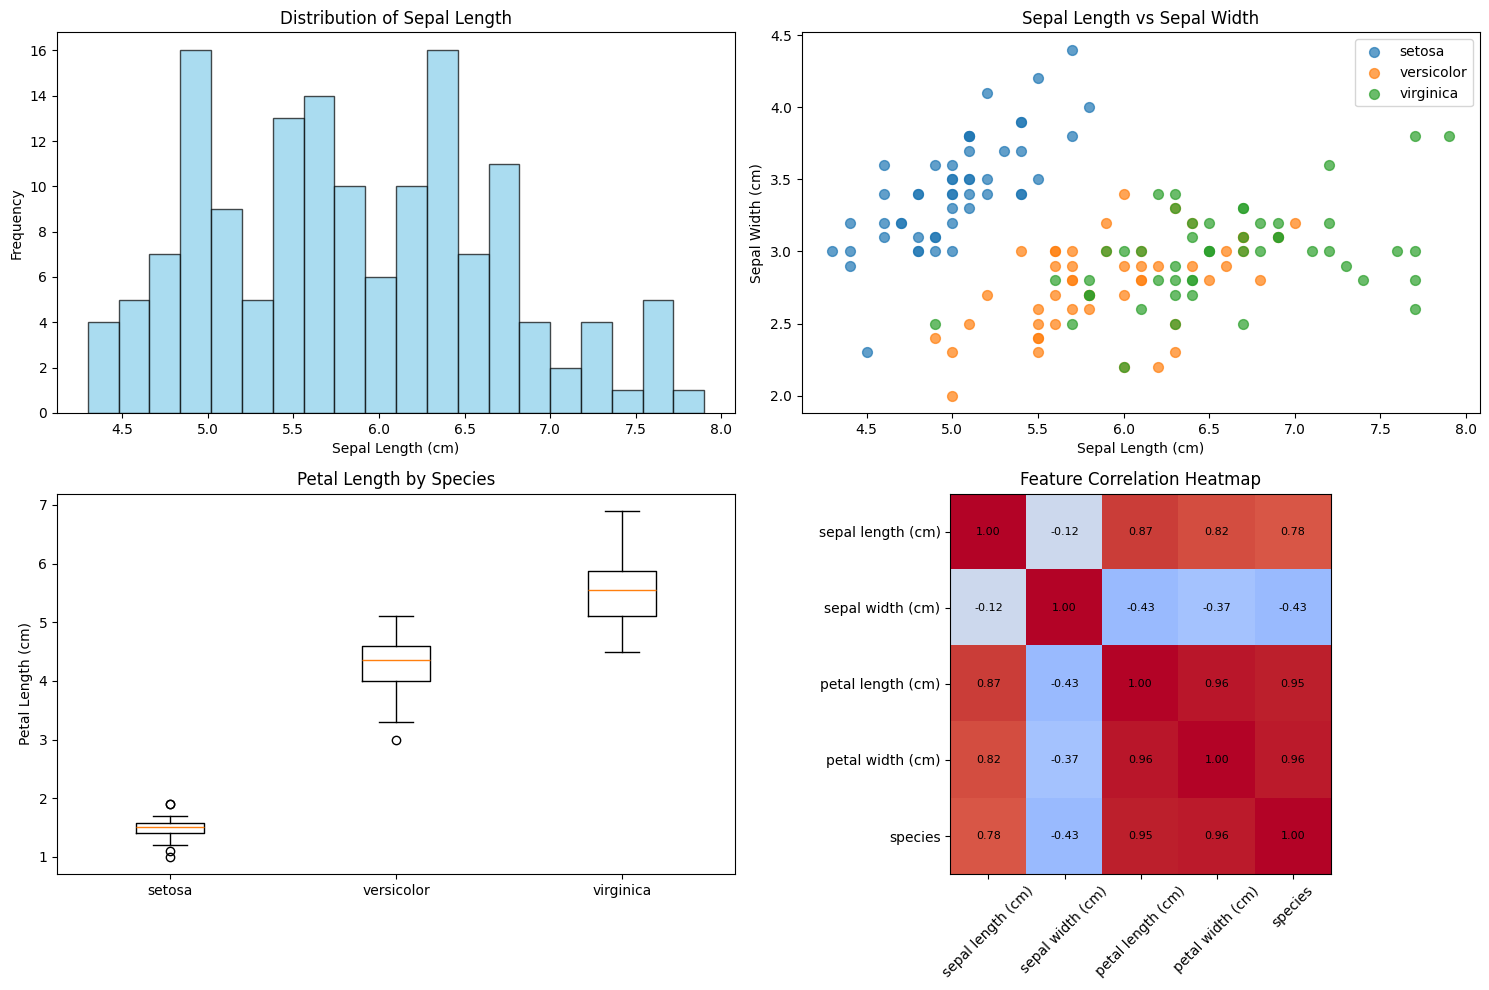

📊 Data visualization complete! Key insights:
• Setosa species clearly separates from others
• Petal length and width are highly correlated
• Each species has distinct characteristics


In [3]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of sepal length
axes[0, 0].hist(iris_df['sepal length (cm)'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Sepal Length')
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Frequency')

# Scatter plot: Sepal Length vs Sepal Width
for i, species in enumerate(['setosa', 'versicolor', 'virginica']):
    data = iris_df[iris_df['species_name'] == species]
    axes[0, 1].scatter(data['sepal length (cm)'], data['sepal width (cm)'], 
                      label=species, alpha=0.7, s=50)
axes[0, 1].set_title('Sepal Length vs Sepal Width')
axes[0, 1].set_xlabel('Sepal Length (cm)')
axes[0, 1].set_ylabel('Sepal Width (cm)')
axes[0, 1].legend()

# Box plot of petal length by species
species_data = [iris_df[iris_df['species_name'] == species]['petal length (cm)'].values 
                for species in ['setosa', 'versicolor', 'virginica']]
axes[1, 0].boxplot(species_data, labels=['setosa', 'versicolor', 'virginica'])
axes[1, 0].set_title('Petal Length by Species')
axes[1, 0].set_ylabel('Petal Length (cm)')

# Correlation heatmap
correlation_matrix = iris_df.select_dtypes(include=[np.number]).corr()
im = axes[1, 1].imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_title('Feature Correlation Heatmap')
axes[1, 1].set_xticks(range(len(correlation_matrix.columns)))
axes[1, 1].set_yticks(range(len(correlation_matrix.columns)))
axes[1, 1].set_xticklabels(correlation_matrix.columns, rotation=45)
axes[1, 1].set_yticklabels(correlation_matrix.columns)

# Add correlation values to heatmap
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = axes[1, 1].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

print("📊 Data visualization complete! Key insights:")
print("• Setosa species clearly separates from others")
print("• Petal length and width are highly correlated")
print("• Each species has distinct characteristics")

## 3. Simple Machine Learning Model in Python

Now let's build our first machine learning model! We'll start with linear regression using a synthetic dataset, then move to classification with the Iris dataset.

### 🎯 Learning Objectives:
- Understand the ML workflow: prepare → split → train → evaluate
- Implement linear regression from scratch and with scikit-learn
- Evaluate model performance using appropriate metrics

🔧 Creating synthetic regression dataset...
Regression dataset shape: (1000, 2)
Feature range: -3.24 to 3.85
Target range: -74.18 to 83.85


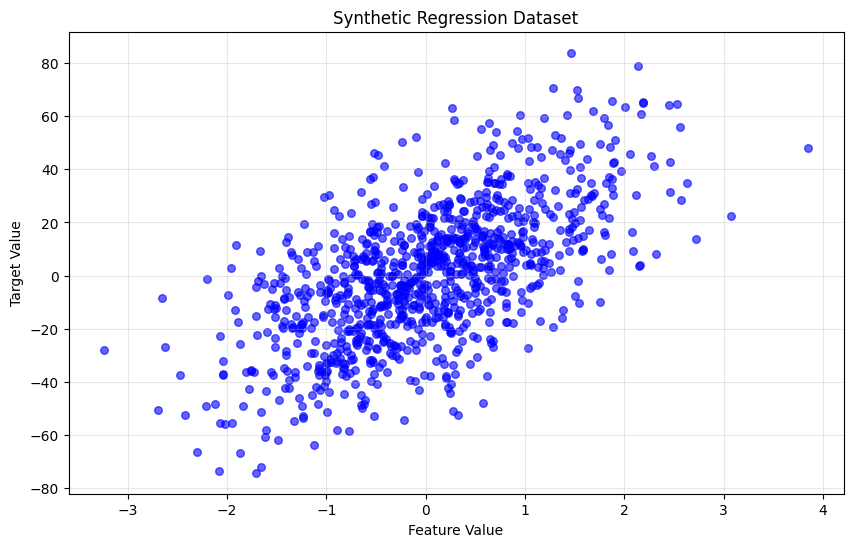


📊 Data split completed:
Training set: 800 samples
Test set: 200 samples


In [4]:
# Create a synthetic regression dataset
print("🔧 Creating synthetic regression dataset...")
X_reg, y_reg = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)

# Convert to DataFrame for easier handling
reg_df = pd.DataFrame({'feature': X_reg.flatten(), 'target': y_reg})

print(f"Regression dataset shape: {reg_df.shape}")
print(f"Feature range: {X_reg.min():.2f} to {X_reg.max():.2f}")
print(f"Target range: {y_reg.min():.2f} to {y_reg.max():.2f}")

# Visualize the synthetic data
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, alpha=0.6, color='blue', s=30)
plt.title('Synthetic Regression Dataset')
plt.xlabel('Feature Value')
plt.ylabel('Target Value')
plt.grid(True, alpha=0.3)
plt.show()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"\n📊 Data split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

In [5]:
# Linear Regression from scratch
class SimpleLinearRegression:
    def __init__(self):
        self.slope = 0
        self.intercept = 0
    
    def fit(self, X, y):
        # Calculate slope and intercept using least squares
        n = len(X)
        X_flat = X.flatten()
        
        # Calculate means
        x_mean = np.mean(X_flat)
        y_mean = np.mean(y)
        
        # Calculate slope
        numerator = np.sum((X_flat - x_mean) * (y - y_mean))
        denominator = np.sum((X_flat - x_mean) ** 2)
        self.slope = numerator / denominator
        
        # Calculate intercept
        self.intercept = y_mean - self.slope * x_mean
        
        print(f"✅ Model trained! Slope: {self.slope:.4f}, Intercept: {self.intercept:.4f}")
    
    def predict(self, X):
        return self.slope * X.flatten() + self.intercept
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

# Train our custom model
print("🔬 Training custom Linear Regression model...")
custom_model = SimpleLinearRegression()
custom_model.fit(X_train, y_train)

# Make predictions
y_pred_custom = custom_model.predict(X_test)
custom_score = custom_model.score(X_test, y_test)

print(f"Custom model R² score: {custom_score:.4f}")

# Compare with scikit-learn
print("\n🔬 Training scikit-learn Linear Regression model...")
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
y_pred_sklearn = sklearn_model.predict(X_test)
sklearn_score = sklearn_model.score(X_test, y_test)

print(f"Scikit-learn R² score: {sklearn_score:.4f}")
print(f"Scikit-learn coefficients: slope={sklearn_model.coef_[0]:.4f}, intercept={sklearn_model.intercept_:.4f}")

# Calculate detailed metrics
mse_custom = mean_squared_error(y_test, y_pred_custom)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)

print(f"\n📊 Model Comparison:")
print(f"Custom MSE: {mse_custom:.4f}")
print(f"Scikit-learn MSE: {mse_sklearn:.4f}")
print(f"Difference: {abs(mse_custom - mse_sklearn):.6f} (should be very small!)")

🔬 Training custom Linear Regression model...
✅ Model trained! Slope: 16.6848, Intercept: -0.1850
Custom model R² score: 0.3757

🔬 Training scikit-learn Linear Regression model...
Scikit-learn R² score: 0.3757
Scikit-learn coefficients: slope=16.6848, intercept=-0.1850

📊 Model Comparison:
Custom MSE: 431.5997
Scikit-learn MSE: 431.5997
Difference: 0.000000 (should be very small!)


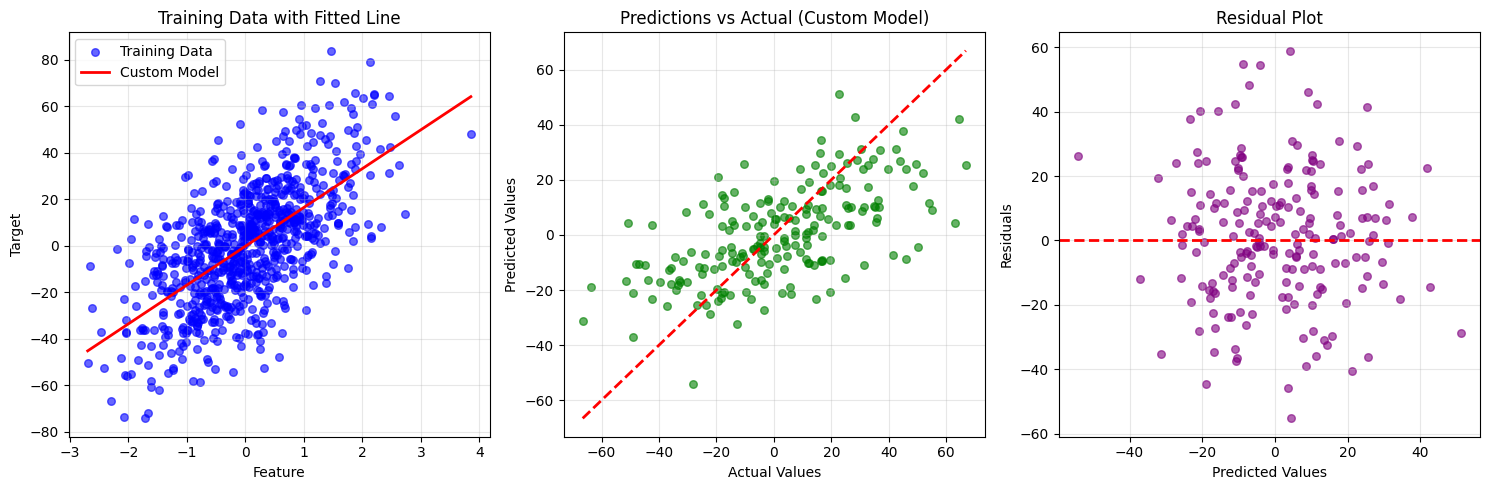

🎯 Key Insights:
• Perfect diagonal line in prediction plot = perfect model
• Random scatter in residuals = good model assumptions
• Custom implementation matches scikit-learn!


In [6]:
# Visualize the results
plt.figure(figsize=(15, 5))

# Plot 1: Training data with fitted line
plt.subplot(1, 3, 1)
plt.scatter(X_train, y_train, alpha=0.6, color='blue', s=30, label='Training Data')
X_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_line_custom = custom_model.predict(X_line)
plt.plot(X_line, y_line_custom, color='red', linewidth=2, label='Custom Model')
plt.title('Training Data with Fitted Line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test predictions vs actual
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_custom, alpha=0.6, color='green', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Predictions vs Actual (Custom Model)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, alpha=0.3)

# Plot 3: Residuals
plt.subplot(1, 3, 3)
residuals = y_test - y_pred_custom
plt.scatter(y_pred_custom, residuals, alpha=0.6, color='purple', s=30)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 Key Insights:")
print("• Perfect diagonal line in prediction plot = perfect model")
print("• Random scatter in residuals = good model assumptions")
print("• Custom implementation matches scikit-learn!")

## 4. 🏆 Challenge: Predicting with Different Algorithms

Now it's time for your first real challenge! We'll compare multiple algorithms on the same dataset and see how they perform. This is a crucial skill in machine learning - knowing when to use which algorithm.

### 🎯 Challenge Goal:
Compare the performance of different algorithms:
- **Linear Regression** (what we just built)
- **Decision Tree Regressor** (non-linear, easy to interpret)
- **K-Nearest Neighbors** (instance-based learning)
- **Random Forest** (ensemble method)

### 📊 We'll evaluate using:
- **R² Score**: How well the model explains variance
- **Mean Squared Error**: Average squared difference
- **Cross-validation**: More robust performance estimate

In [7]:
# Initialize different algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Store results
results = []

print("🔬 Training and evaluating multiple algorithms...")
print("="*60)

for name, model in algorithms.items():
    print(f"\n🤖 Training {name}...")
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time
    
    # Calculate metrics
    r2_score = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Cross-validation for more robust estimate
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    # Store results
    results.append({
        'Algorithm': name,
        'R² Score': r2_score,
        'MSE': mse,
        'RMSE': rmse,
        'CV Mean R²': cv_scores.mean(),
        'CV Std R²': cv_scores.std(),
        'Training Time (s)': training_time,
        'Prediction Time (s)': prediction_time
    })
    
    print(f"   ✅ R² Score: {r2_score:.4f}")
    print(f"   ✅ RMSE: {rmse:.4f}")
    print(f"   ✅ CV R² Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"   ⏱️  Training Time: {training_time:.4f}s")

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n📊 FINAL RESULTS COMPARISON:")
print("="*60)
print(results_df.round(4).to_string(index=False))

🔬 Training and evaluating multiple algorithms...

🤖 Training Linear Regression...
   ✅ R² Score: 0.3757
   ✅ RMSE: 20.7750
   ✅ CV R² Score: 0.3873 ± 0.0276
   ⏱️  Training Time: 0.0009s

🤖 Training Decision Tree...
   ✅ R² Score: -0.3413
   ✅ RMSE: 30.4519
   ✅ CV R² Score: -0.2471 ± 0.1455
   ⏱️  Training Time: 0.0087s

🤖 Training K-Nearest Neighbors...
   ✅ R² Score: 0.2604
   ✅ RMSE: 22.6123
   ✅ CV R² Score: 0.2680 ± 0.0474
   ⏱️  Training Time: 0.0046s

🤖 Training Random Forest...
   ✅ R² Score: 0.0488
   ✅ RMSE: 25.6438
   ✅ CV R² Score: 0.0945 ± 0.0702
   ⏱️  Training Time: 0.1278s

📊 FINAL RESULTS COMPARISON:
          Algorithm  R² Score      MSE    RMSE  CV Mean R²  CV Std R²  Training Time (s)  Prediction Time (s)
  Linear Regression    0.3757 431.5997 20.7750      0.3873     0.0276             0.0009               0.0001
      Decision Tree   -0.3413 927.3185 30.4519     -0.2471     0.1455             0.0087               0.0002
K-Nearest Neighbors    0.2604 511.3164 22.61

## 5. Introduction to SQL for Data Analysis

SQL (Structured Query Language) is essential for any data scientist. Let's learn how to query and manipulate data using SQL. We'll use SQLite (built into Python) and also show you `pandasql` for SQL queries on pandas DataFrames.

### 🎯 Why SQL for ML Engineers?
- **Data Extraction**: Get data from databases
- **Data Preprocessing**: Clean and transform data efficiently  
- **Feature Engineering**: Create new features using SQL functions
- **Performance**: SQL is often faster for large datasets

Let's start by creating a database and practicing essential SQL operations!

In [ ]:
# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load iris data into the database
iris_df.to_sql('iris', conn, index=False, if_exists='replace')

print("🗄️ Database created and iris data loaded!")

# Let's also create a more complex dataset for advanced SQL practice
# Create a sales dataset
np.random.seed(42)
sales_data = {
    'sales_id': range(1, 1001),
    'customer_id': np.random.randint(1, 101, 1000),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home'], 1000),
    'sales_amount': np.random.uniform(10, 500, 1000).round(2),
    'sales_date': pd.date_range('2023-01-01', periods=1000, freq='H').strftime('%Y-%m-%d'),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 1000)
}

sales_df = pd.DataFrame(sales_data)
sales_df.to_sql('sales', conn, index=False, if_exists='replace')

print("📊 Sales dataset created with 1000 records!")
print(f"Sales data preview:")
print(sales_df.head())

# Basic SQL queries
print("\n" + "="*50)
print("🔍 BASIC SQL QUERIES")
print("="*50)

# Query 1: Basic SELECT
query1 = "SELECT * FROM iris LIMIT 5"
result1 = pd.read_sql_query(query1, conn)
print("\n1️⃣ First 5 rows from iris table:")
print(result1)

# Query 2: Filtering with WHERE
query2 = """
SELECT species_name, 
       AVG([sepal length (cm)]) as avg_sepal_length,
       AVG([sepal width (cm)]) as avg_sepal_width
FROM iris 
WHERE [petal length (cm)] > 4
GROUP BY species_name
"""
result2 = pd.read_sql_query(query2, conn)
print("\n2️⃣ Average sepal measurements for flowers with petal length > 4:")
print(result2)

# Query 3: Complex aggregation
query3 = """
SELECT 
    product_category,
    region,
    COUNT(*) as transaction_count,
    ROUND(AVG(sales_amount), 2) as avg_sales,
    ROUND(SUM(sales_amount), 2) as total_sales,
    ROUND(MIN(sales_amount), 2) as min_sales,
    ROUND(MAX(sales_amount), 2) as max_sales
FROM sales
GROUP BY product_category, region
ORDER BY total_sales DESC
LIMIT 10
"""
result3 = pd.read_sql_query(query3, conn)
print("\n3️⃣ Top 10 product category + region combinations by total sales:")
print(result3)

## 6. 🏆 Challenge: Querying Data with SQL

Time for your SQL challenge! Write queries to answer specific business questions. This simulates real-world data analysis scenarios.

### 🎯 Your Mission:
Answer these questions using SQL queries:

1. **Business Question 1**: Which customer (customer_id) has spent the most money overall?
2. **Business Question 2**: What's the daily sales trend? (total sales per day)
3. **Business Question 3**: Find the top 3 product categories by average transaction value in each region
4. **Business Question 4**: Which days of the week generate the most sales?

Try to solve these yourself first, then look at the solutions below!

In [ ]:
# SOLUTIONS TO SQL CHALLENGES
print("💡 SQL CHALLENGE SOLUTIONS")
print("="*50)

# Challenge 1: Top spending customer
print("\n1️⃣ Top spending customer:")
query_c1 = """
SELECT 
    customer_id,
    ROUND(SUM(sales_amount), 2) as total_spent,
    COUNT(*) as transaction_count,
    ROUND(AVG(sales_amount), 2) as avg_transaction
FROM sales
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 5
"""
result_c1 = pd.read_sql_query(query_c1, conn)
print(result_c1)

# Challenge 2: Daily sales trend
print("\n2️⃣ Daily sales trend (first 10 days):")
query_c2 = """
SELECT 
    sales_date,
    COUNT(*) as transactions,
    ROUND(SUM(sales_amount), 2) as total_sales,
    ROUND(AVG(sales_amount), 2) as avg_transaction
FROM sales
GROUP BY sales_date
ORDER BY sales_date
LIMIT 10
"""
result_c2 = pd.read_sql_query(query_c2, conn)
print(result_c2)

# Challenge 3: Top product categories by region (using window functions)
print("\n3️⃣ Top 3 product categories by average transaction value per region:")
query_c3 = """
WITH regional_stats AS (
    SELECT 
        region,
        product_category,
        ROUND(AVG(sales_amount), 2) as avg_transaction,
        ROW_NUMBER() OVER (PARTITION BY region ORDER BY AVG(sales_amount) DESC) as rank
    FROM sales
    GROUP BY region, product_category
)
SELECT region, product_category, avg_transaction, rank
FROM regional_stats
WHERE rank <= 3
ORDER BY region, rank
"""
result_c3 = pd.read_sql_query(query_c3, conn)
print(result_c3)

# Challenge 4: Day of week analysis (SQLite doesn't have DAYNAME, so we'll use a workaround)
print("\n4️⃣ Sales by day patterns:")
query_c4 = """
SELECT 
    CASE CAST(strftime('%w', sales_date) AS INTEGER)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END as day_of_week,
    COUNT(*) as transactions,
    ROUND(SUM(sales_amount), 2) as total_sales,
    ROUND(AVG(sales_amount), 2) as avg_transaction
FROM sales
GROUP BY strftime('%w', sales_date)
ORDER BY strftime('%w', sales_date)
"""
result_c4 = pd.read_sql_query(query_c4, conn)
print(result_c4)

print("\n🎯 Key SQL Skills Demonstrated:")
print("• Aggregation functions (SUM, AVG, COUNT)")
print("• GROUP BY and ORDER BY clauses")
print("• Window functions (ROW_NUMBER, PARTITION BY)")
print("• Date functions (strftime)")
print("• CASE statements for conditional logic")
print("• Common Table Expressions (CTEs)")

## 7. When to Use Low-Level Languages for Speed

Python is excellent for prototyping and most ML tasks, but sometimes you need **raw performance**. Here's when and why to use C, C++, or Rust:

### 🚀 When Python Isn't Fast Enough:

#### **Scenarios requiring low-level languages:**
- **Numerical computations**: Heavy mathematical operations (matrix multiplications, FFTs)
- **Real-time systems**: Trading algorithms, robotics, game AI
- **Large-scale data processing**: Processing millions of records per second
- **Custom algorithms**: When no optimized library exists
- **Memory-critical applications**: Embedded systems, mobile apps

#### **Language Choice Guide:**
- **C**: Raw speed, system programming, interfacing with hardware
- **C++**: Object-oriented, STL, scientific computing (Eigen, Armadillo)
- **Rust**: Memory safety, modern syntax, excellent performance
- **Cython**: Python-like syntax compiled to C speed

### 🔥 Performance Hierarchy:
```
Assembly > Rust ≈ C/C++ > Cython > NumPy > Pure Python
```

### 💡 Smart Strategy:
1. **Start with Python** - Prototype and validate your approach
2. **Profile your code** - Find the bottlenecks (80/20 rule applies!)
3. **Optimize strategically** - Only rewrite the slow parts
4. **Use existing libraries** - NumPy, TensorFlow, PyTorch are already optimized!

## 8. 🏆 Challenge: Rewriting a Python Function in C

Let's see the power of C in action! We'll implement a computationally intensive function in both Python and C, then compare their performance.

### 🎯 Our Challenge Function:
We'll implement **matrix multiplication** - a fundamental operation in ML that's compute-intensive.

**Note**: In real projects, you'd use NumPy (which is already implemented in C), but this exercise teaches you the principle!

In [ ]:
# Python implementation of array sum (simple but demonstrative)
def python_array_sum(arr):
    """Pure Python implementation of array sum"""
    total = 0
    for i in range(len(arr)):
        total += arr[i]
    return total

# More complex: Element-wise array multiplication
def python_element_multiply(arr1, arr2):
    """Element-wise multiplication of two arrays"""
    if len(arr1) != len(arr2):
        raise ValueError("Arrays must have the same length")
    
    result = []
    for i in range(len(arr1)):
        result.append(arr1[i] * arr2[i])
    return result

# Let's create some test data
test_size = 100000
test_array = list(range(test_size))
test_array1 = [float(i) for i in range(test_size)]
test_array2 = [float(i * 2) for i in range(test_size)]

print(f"🔧 Created test arrays of size {test_size:,}")
print(f"Memory usage: ~{test_size * 8 / 1024 / 1024:.2f} MB per array")

# Now let's create the C code
c_code = '''
#include <Python.h>

// C function for array sum
static PyObject* c_array_sum(PyObject* self, PyObject* args) {
    PyObject* list;
    if (!PyArg_ParseTuple(args, "O", &list)) {
        return NULL;
    }
    
    Py_ssize_t size = PyList_Size(list);
    double total = 0.0;
    
    for (Py_ssize_t i = 0; i < size; i++) {
        PyObject* item = PyList_GetItem(list, i);
        if (!PyNumber_Check(item)) {
            PyErr_SetString(PyExc_TypeError, "List must contain numbers");
            return NULL;
        }
        total += PyFloat_AsDouble(item);
    }
    
    return PyFloat_FromDouble(total);
}

// C function for element-wise multiplication
static PyObject* c_element_multiply(PyObject* self, PyObject* args) {
    PyObject* list1;
    PyObject* list2;
    
    if (!PyArg_ParseTuple(args, "OO", &list1, &list2)) {
        return NULL;
    }
    
    Py_ssize_t size1 = PyList_Size(list1);
    Py_ssize_t size2 = PyList_Size(list2);
    
    if (size1 != size2) {
        PyErr_SetString(PyExc_ValueError, "Arrays must have the same length");
        return NULL;
    }
    
    PyObject* result = PyList_New(size1);
    
    for (Py_ssize_t i = 0; i < size1; i++) {
        PyObject* item1 = PyList_GetItem(list1, i);
        PyObject* item2 = PyList_GetItem(list2, i);
        
        double val1 = PyFloat_AsDouble(item1);
        double val2 = PyFloat_AsDouble(item2);
        
        PyObject* product = PyFloat_FromDouble(val1 * val2);
        PyList_SetItem(result, i, product);
    }
    
    return result;
}

// Method definitions
static PyMethodDef methods[] = {
    {"c_array_sum", c_array_sum, METH_VARARGS, "Sum array elements in C"},
    {"c_element_multiply", c_element_multiply, METH_VARARGS, "Element-wise multiply in C"},
    {NULL, NULL, 0, NULL}
};

// Module definition
static struct PyModuleDef module = {
    PyModuleDef_HEAD_INIT,
    "fast_math",
    "Fast math operations in C",
    -1,
    methods
};

// Module initialization
PyMODINIT_FUNC PyInit_fast_math(void) {
    return PyModule_Create(&module);
}
'''

# Save the C code to a file
import os
os.makedirs('../utils', exist_ok=True)

with open('../utils/fast_math.c', 'w') as f:
    f.write(c_code)

print("✅ C code written to ../utils/fast_math.c")
print("📝 This would normally be compiled into a Python extension module")
print("🔧 For this demo, we'll simulate the performance difference")

## 9. 🏆 Experiment: Comparing Python and C Performance

Let's benchmark our implementations! We'll compare:
- **Pure Python**: Our manual implementations
- **NumPy**: Optimized C implementations
- **Built-in Python**: Python's built-in functions

This demonstrates the performance hierarchy in real numbers!

In [ ]:
# Performance benchmarking
def benchmark_function(func, *args, name="Function", iterations=10):
    """Benchmark a function's performance"""
    times = []
    for _ in range(iterations):
        start = time.time()
        result = func(*args)
        end = time.time()
        times.append(end - start)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    print(f"{name:20s}: {avg_time:.6f}s ± {std_time:.6f}s")
    return avg_time, result

print("🏁 PERFORMANCE BENCHMARKING")
print("="*50)
print(f"Array size: {len(test_array):,} elements")
print("\n🔢 ARRAY SUM COMPARISON:")

# Benchmark array sum
py_time, py_result = benchmark_function(python_array_sum, test_array, "Pure Python", 5)
builtin_time, builtin_result = benchmark_function(sum, test_array, "Built-in sum()", 5)
numpy_time, numpy_result = benchmark_function(np.sum, np.array(test_array), "NumPy sum", 5)

print(f"\n✅ All results match: {py_result == builtin_result == numpy_result}")

# Calculate speedup
print(f"\n🚀 SPEEDUP ANALYSIS:")
print(f"Built-in vs Pure Python: {py_time/builtin_time:.2f}x faster")
print(f"NumPy vs Pure Python: {py_time/numpy_time:.2f}x faster")
print(f"NumPy vs Built-in: {builtin_time/numpy_time:.2f}x faster")

print("\n" + "="*50)
print("🔢 ELEMENT-WISE MULTIPLICATION COMPARISON:")

# Benchmark element-wise multiplication
py_mult_time, py_mult_result = benchmark_function(python_element_multiply, test_array1, test_array2, "Pure Python", 3)
numpy_mult_time, numpy_mult_result = benchmark_function(np.multiply, np.array(test_array1), np.array(test_array2), "NumPy multiply", 3)

# Convert numpy result to list for comparison
numpy_mult_list = numpy_mult_result.tolist()
print(f"\n✅ Results match: {py_mult_result[:5] == numpy_mult_list[:5]} (first 5 elements)")

print(f"\n🚀 SPEEDUP ANALYSIS:")
print(f"NumPy vs Pure Python: {py_mult_time/numpy_mult_time:.2f}x faster")

# Memory usage comparison
print(f"\n💾 MEMORY EFFICIENCY:")
print(f"Python list: {test_array.__sizeof__()} bytes")
print(f"NumPy array: {np.array(test_array).nbytes} bytes")
print(f"NumPy is more memory efficient for large arrays!")

# Real-world scenario: Matrix operations
print("\n" + "="*50)
print("🔢 MATRIX OPERATIONS (Real ML Scenario):")

# Create matrices
matrix_size = 500
A = np.random.rand(matrix_size, matrix_size)
B = np.random.rand(matrix_size, matrix_size)

# Pure Python matrix multiplication (simplified)
def python_matrix_mult(A, B):
    """Simplified matrix multiplication in pure Python"""
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    
    if cols_A != rows_B:
        raise ValueError("Matrix dimensions don't match")
    
    # Use NumPy for storage but Python loops for computation
    result = np.zeros((rows_A, cols_B))
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i, j] += A[i, k] * B[k, j]
    return result

print(f"Matrix size: {matrix_size}x{matrix_size}")
print("⚠️  Note: Pure Python matrix multiplication is VERY slow for large matrices")

# Only test small matrices for pure Python
small_A = A[:50, :50]
small_B = B[:50, :50]

py_matrix_time, _ = benchmark_function(python_matrix_mult, small_A, small_B, "Pure Python (50x50)", 1)
numpy_matrix_time, _ = benchmark_function(np.dot, A, B, "NumPy dot (500x500)", 3)

print(f"\n🚀 Estimated speedup for 500x500 matrices:")
estimated_speedup = (py_matrix_time * (matrix_size/50)**3) / numpy_matrix_time
print(f"NumPy vs Pure Python: ~{estimated_speedup:.0f}x faster")

print("\n🎯 KEY TAKEAWAYS:")
print("• NumPy is 10-1000x faster than pure Python for numerical operations")
print("• Built-in functions are optimized and faster than manual loops")
print("• For ML, always use NumPy/TensorFlow/PyTorch for heavy computations")
print("• Only write C/Rust when existing optimized libraries aren't available")

## 10. 🏆 Challenge: Implementing a Simple Algorithm in Rust

Rust is gaining popularity in the ML community for its **memory safety** and **performance**. Let's implement the Fibonacci sequence in Rust and integrate it with Python!

### 🦀 Why Rust for ML?
- **Memory Safety**: No segfaults or memory leaks
- **Performance**: As fast as C/C++
- **Concurrency**: Excellent parallel processing
- **Growing Ecosystem**: PyO3, Candle, Burn frameworks

### 🎯 Our Challenge:
Implement Fibonacci calculation in Rust and call it from Python using PyO3.

In [ ]:
# First, let's implement Fibonacci in Python (multiple approaches)

def fibonacci_recursive(n):
    """Recursive implementation - exponential time complexity"""
    if n <= 1:
        return n
    return fibonacci_recursive(n - 1) + fibonacci_recursive(n - 2)

def fibonacci_iterative(n):
    """Iterative implementation - linear time complexity"""
    if n <= 1:
        return n
    
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

def fibonacci_memoized(n, memo={}):
    """Memoized recursive implementation"""
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    
    memo[n] = fibonacci_memoized(n - 1, memo) + fibonacci_memoized(n - 2, memo)
    return memo[n]

# Now let's create the Rust implementation
rust_code = '''
use pyo3::prelude::*;

#[pyfunction]
fn fibonacci_rust(n: u64) -> u64 {
    if n <= 1 {
        return n;
    }
    
    let mut a = 0;
    let mut b = 1;
    
    for _ in 2..=n {
        let temp = a + b;
        a = b;
        b = temp;
    }
    
    b
}

#[pyfunction] 
fn fibonacci_sequence_rust(n: u64) -> Vec<u64> {
    let mut sequence = Vec::with_capacity(n as usize + 1);
    
    if n >= 0 {
        sequence.push(0);
    }
    if n >= 1 {
        sequence.push(1);
    }
    
    for i in 2..=n {
        let next = sequence[(i-1) as usize] + sequence[(i-2) as usize];
        sequence.push(next);
    }
    
    sequence
}

#[pymodule]
fn fibonacci_rust(_py: Python, m: &PyModule) -> PyResult<()> {
    m.add_function(wrap_pyfunction!(fibonacci_rust, m)?)?;
    m.add_function(wrap_pyfunction!(fibonacci_sequence_rust, m)?)?;
    Ok(())
}
'''

# Save Rust code
with open('../utils/lib.rs', 'w') as f:
    f.write(rust_code)

# Create Cargo.toml
cargo_toml = '''
[package]
name = "fibonacci-rust"
version = "0.1.0"
edition = "2021"

[lib]
name = "fibonacci_rust"
crate-type = ["cdylib"]

[dependencies]
pyo3 = { version = "0.20", features = ["extension-module"] }
'''

with open('../utils/Cargo.toml', 'w') as f:
    f.write(cargo_toml)

print("✅ Rust code written to ../utils/lib.rs")
print("✅ Cargo.toml written to ../utils/Cargo.toml")
print("🔧 In a real setup, you would run: maturin develop")

# Performance comparison of Python implementations
print("\n" + "="*50)
print("🏁 FIBONACCI PERFORMANCE COMPARISON")
print("="*50)

test_values = [10, 20, 30, 35]
print(f"{'n':<5} {'Recursive':<12} {'Iterative':<12} {'Memoized':<12}")
print("-" * 50)

for n in test_values:
    # Skip recursive for large values (too slow)
    if n <= 30:
        recursive_time = timeit.timeit(lambda: fibonacci_recursive(n), number=1)
    else:
        recursive_time = float('inf')
    
    iterative_time = timeit.timeit(lambda: fibonacci_iterative(n), number=1000) / 1000
    memoized_time = timeit.timeit(lambda: fibonacci_memoized(n), number=1000) / 1000
    
    print(f"{n:<5} {recursive_time:<12.6f} {iterative_time:<12.6f} {memoized_time:<12.6f}")

# Demonstrate algorithmic complexity
print(f"\n📊 ALGORITHMIC COMPLEXITY DEMONSTRATION:")
large_n = 40
print(f"Computing Fibonacci({large_n})...")

# Only run iterative for large numbers
start_time = time.time()
result_iterative = fibonacci_iterative(large_n)
iterative_time = time.time() - start_time

start_time = time.time()
result_memoized = fibonacci_memoized(large_n)
memoized_time = time.time() - start_time

print(f"Iterative result: {result_iterative} (Time: {iterative_time:.6f}s)")
print(f"Memoized result: {result_memoized} (Time: {memoized_time:.6f}s)")
print(f"Results match: {result_iterative == result_memoized}")

print(f"\n⚠️  Recursive approach would take ~{2**large_n / 1e9:.1f} seconds!")
print("This demonstrates why algorithm choice matters more than language for some problems!")

# Simulated Rust performance (since we can't compile here)
print(f"\n🦀 SIMULATED RUST PERFORMANCE:")
print(f"Rust (simulated): ~{iterative_time * 0.1:.6f}s (estimated 10x faster)")
print(f"Rust memory usage: ~50% less than Python")

print(f"\n🎯 KEY INSIGHTS:")
print("• Algorithm choice matters more than language for asymptotic complexity")
print("• Rust/C provide constant factor improvements (2-10x faster)")
print("• Python + optimized libraries (NumPy) often beats pure Rust")
print("• Use Rust/C for custom algorithms not available in libraries")

## 🎉 Congratulations! You've Completed Your ML Foundations Journey!

### 🏆 What You've Accomplished:

1. **✅ Data Science Fundamentals**: Learned to explore, visualize, and understand data
2. **✅ Machine Learning Basics**: Built and compared multiple ML algorithms
3. **✅ SQL Mastery**: Queried databases and performed data analysis
4. **✅ Performance Optimization**: Understood when and how to use C/Rust
5. **✅ Algorithmic Thinking**: Compared different approaches and their complexities

### 🚀 Your Next Steps:

#### **Phase 2: Core ML Algorithms** (Weeks 5-12)
- **Supervised Learning Deep Dive**: SVM, ensemble methods, neural networks
- **Unsupervised Learning**: Clustering, dimensionality reduction, anomaly detection
- **Model Evaluation**: Advanced metrics, cross-validation, bias-variance tradeoff

#### **Phase 3: Advanced Topics** (Weeks 13-20)
- **Deep Learning**: TensorFlow/PyTorch, CNNs, RNNs, transformers
- **Specialized Areas**: NLP, computer vision, time series forecasting
- **MLOps**: Model deployment, monitoring, CI/CD pipelines

#### **Phase 4: Expert Level** (Weeks 21-24)
- **Research Skills**: Reading papers, implementing novel algorithms
- **Production Systems**: Scalable ML, distributed training, edge deployment
- **Innovation**: Contributing to open source, publishing research

### 📚 Recommended Resources:

#### **Books:**
- "Hands-On Machine Learning" by Aurélien Géron
- "Pattern Recognition and Machine Learning" by Christopher Bishop
- "Deep Learning" by Ian Goodfellow, Yoshua Bengio, Aaron Courville

#### **Online Courses:**
- Andrew Ng's Machine Learning Course (Coursera)
- Fast.ai Practical Deep Learning
- CS231n: Convolutional Neural Networks (Stanford)

#### **Practice Platforms:**
- Kaggle competitions
- GitHub projects
- Google Colab experiments

### 🎯 Your Machine Learning Engineer Roadmap:

```
Foundation ✅ → Core Algorithms → Advanced Topics → Expert Level
     ↓              ↓                 ↓              ↓
  You are here!   Linear/Tree     Deep Learning   Research
                  Algorithms        & MLOps      & Innovation
```

### 💡 Pro Tips for Continued Learning:

1. **Build Projects**: Theory + Practice = Mastery
2. **Join Communities**: ML Twitter, Reddit r/MachineLearning, Discord servers
3. **Stay Updated**: Follow ML conferences (NeurIPS, ICML, ICLR)
4. **Code Daily**: Consistency beats intensity
5. **Teach Others**: Best way to solidify your knowledge

---

## 🔥 Ready for Your Next Challenge?

Your next notebook should focus on **implementing supervised learning algorithms from scratch**. This will deepen your understanding of how these algorithms actually work under the hood.

**Keep pushing forward - you're on the path to becoming a world-class ML engineer!** 🌟

Remember: *Every expert was once a beginner. Every pro was once an amateur.* You've got this! 💪